# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Mounted at /content/drive
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
Already up to date.


## Import Libraries

In [2]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
import pickle
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from PIL import Image

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE
from tools.feature_selection import (
    get_feature_importance,
    plot_feature_importance_comparison,
    perm_importance,
    plot_perm_importance_comparison,
    rfe_importance,
    plot_rfe_importance)
from tools.distribution import plot_target_var_distribution
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

## Import Datasets

Here we will import our version 2 of our dataasets that include energy variables and we will also combine the buffer zone datasets into one.

In [ ]:
train_combined, test_combined = combine_buffer_datasets('data/train/v2', 'data/test/v2')

Loading training data: data/train/v2/50m_buffer_dataset.csv
Loading test data: data/test/v2/50m_buffer_test_dataset.csv
Loading training data: data/train/v2/100m_buffer_dataset.csv
Loading test data: data/test/v2/100m_buffer_test_dataset.csv
Loading training data: data/train/v2/150m_buffer_dataset.csv
Loading test data: data/test/v2/150m_buffer_test_dataset.csv
Loading training data: data/train/v2/300m_buffer_dataset.csv
Loading test data: data/test/v2/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 125)
Final Test Dataset Shape: (1040, 126)


In [ ]:
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined, energy_features=True)


Final Processed Training Dataset Shape: (11229, 284)
Final Processed Testing Dataset Shape: (1040, 285)


# Mixed Buffers RandomForestRegressor

This notebook is for creating a new RandomForestRegressor with a mixture of buffer zones. For details on the train/test dataset refer to our past notebook:
- [09_adding_energy_data](09_adding_energy_data.ipynb)


## Preprocessing

First, we will seperate the target variable and scale the data.

In [ ]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

#scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

#split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=VALID_SPLIT, random_state=RANDOM_STATE
)

#make into df
x_train_df = pd.DataFrame(X_train, columns=X.columns)
x_valid_df = pd.DataFrame(X_valid, columns=X.columns)

## Feature Selection

Next, we will do feature selection. We now have interaction terms and a mixture of variables in different buffer zone measurements, so the dataset is filled with a lot of features that need to be dropped.

In [ ]:
# Base Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=rf, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

In [ ]:
# save the selected features so we don't have to run again
selected_feature_names=['50m_NDWI', '50m_1NPCRI', '50m_1Building_Construction_Year',
                        '50m_1Ground_Elevation', '50m_1Fuel_Oil_2_Use_kBtu', '50m_1Fuel_Oil_4_Use_kBtu',
                        '50m_1Electricity_Use_Grid_Purchase_kBtu', '50m_Building_Wind_Y', '50m_Elevation_Wind_Y',
                        '50m_Traffic_NDVI', '100m_NDVI', '100m_SI', '100m_NPCRI', '100m_Coastal_Aerosol',
                        '100m_Building_Construction_Year', '100m_Elevation_Wind_X', '100m_BldgHeight_Count',
                        '100m_Humidity_NDVI', '100m_Water_Use_Per_Area', '100m_Fuel_Dependency',
                        '150m_Building_Wind_X', '150m_Elevation_Wind_Y', '150m_Temp_BuildingDensity',
                        '150m_Building_Aspect_Ratio', '150m_Permeable_Impermeable_Ratio', '150m_Water_Use_Per_Area',
                        '150m_Fuel_Dependency', '300m_NDWI', '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol',
                        '300m_Building_Count', '300m_Building_Construction_Year', '300m_Ground_Elevation',
                        '300m_Weather_Normalized_Site_EUI_kBtu_ft2', '300m_Fuel_Oil_2_Use_kBtu', '300m_Fuel_Oil_4_Use_kBtu',
                        '300m_Direct_GHG_Emissions_MetricTons_CO2e', '300m_Water_Use_All_Sources_kgal', '300m_Building_Wind_X',
                        '300m_Building_Wind_Y', '300m_Elevation_Wind_X', '300m_Elevation_Wind_Y', '300m_BldgHeight_Count',
                        '300m_BuildingDensity_NDVI', '300m_Traffic_NDVI', '300m_Temp_BuildingDensity', '300m_Traffic_NDBI',
                        '300m_BuildingAge_Temp', '300m_Building_Aspect_Ratio', '300m_Urban_Material_Index', '300m_Permeable_Impermeable_Ratio',
                        '300m_Land_Surface_Albedo', '300m_Canopy_Cover_Ratio', '300m_Soil_Moisture_Index', '300m_Traffic_Heat_Emission',
                        '300m_GHG_Proxy', '300m_Energy_Use_Per_Building', '300m_Fuel_Dependency']

Here we see the features that were selected. These features maximized the cross-validation score. Now let's select them for our training/validation set.

In [ ]:
# select features
x_train_selected = pd.DataFrame(X_train, columns=x_train_df.columns)[selected_feature_names]
x_valid_selected = pd.DataFrame(X_valid, columns=x_train_df.columns)[selected_feature_names]

Now that we have the selected features, let's re do the scaler so that the saved scaler only accepts the selected features.

In [ ]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

# only selected
X = X[selected_feature_names]

#scaler
scaler = StandardScaler()
scaler.fit_transform(X)

array([[-0.36502564,  1.0452182 ,  0.31687682, ..., -0.31552992,
        -0.21589026,  0.29897671],
       [-0.49237841,  1.00075169,  0.3115036 , ..., -0.3223217 ,
        -0.21348207,  0.30589169],
       [-0.59826107,  0.95394058,  0.30177366, ..., -0.32329196,
        -0.21317333,  0.30589169],
       ...,
       [-3.00323495, -2.35688867, -5.56959407, ..., -0.31731005,
         7.52007469,  0.19950779],
       [-2.9821176 , -2.38442392, -5.56959407, ..., -0.31731005,
         7.52007469,  0.19950779],
       [-2.97101092, -2.41880827, -5.56959407, ..., -0.31731005,
         7.52007469,  0.19950779]])

## Hyperparameter Tuning

Now we will tune the Random Forest Regressor hyperparemeters using `GridSearchCV`.

In [ ]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Initialize model
rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

# Grid search with selected features
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Fit grid search to the **selected features only**
grid_search.fit(x_train_selected, y_train)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R-squared Score:", grid_search.best_score_)

In [ ]:
# save the best params so we don't have to run again
best_hparams = {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Here we see the hyper params for the best model and the R-squared it got. Let's retrieve the best model.

In [ ]:
# best model, skip if model was already generated
model_pkl = 'models/mixed_buffers_RandomForestRegressor/mixed_buffers_RandomForestRegressor_model.pkl'
if not os.path.exists(model_pkl):
  best_rf_model = grid_search.best_estimator_
else:
  with open(model_pkl, 'rb') as f:
    best_rf_model = pickle.load(f)

## In-Sample Evaluation

In [ ]:
# Make predictions on the training data
insample_predictions = best_rf_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

In-Sample Evaluation:
  Mixed buffers zone R-squared: 1.0


## Out-Sample Evaluation

In [ ]:
# Make predictions on the validation data
outsample_predictions = best_rf_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffers zone R-squared: {outsample_r2}")

Out-Sample Evaluation:
  Mixed buffers zone R-squared: 0.969685199482678


# Challenge Submission

We will now submit our mixed buffers `RandomForestRegressor` model to the challenge.
>NOTE: We can have multiple submissions.

In [ ]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

#select features
test_dataset = test_dataset[selected_feature_names]

#scale
x_test = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index).values

# Model prediction
test_predictions = best_rf_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions
})
submission_df

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.964205
1,-73.971928,40.788875,0.964318
2,-73.967080,40.789080,0.965934
3,-73.972550,40.789082,0.963806
4,-73.969697,40.787953,0.960014
...,...,...,...
1035,-73.919388,40.813803,1.037145
1036,-73.931033,40.833178,1.039613
1037,-73.934647,40.854542,1.040093
1038,-73.917223,40.815413,1.037831


Save the submission dataframe to submit into challenge portal:

In [ ]:
submission_df.to_csv("mixed_buffers_RandomForestRegressor_model_submission.csv", index=False)

Score We Received:

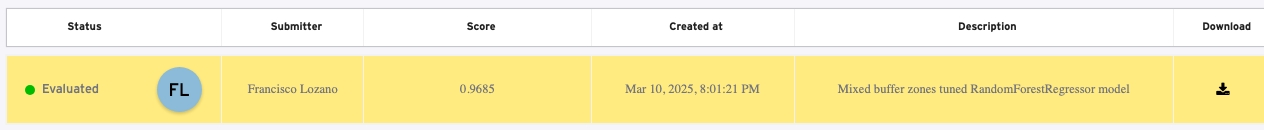

In [4]:
Image.open('images/mixed_buffers_RandomForestRegressor_model_score.jpeg')

Our Mixed Buffer RandomForestRegressor did better than our 300m tuned RandomForestRegressor.

# Understanding the Results

Now we will use SHAP to understand the results. SHAP can show us feature importance, ranking, understand feature vs. prediction relationships, and can even explain individual predictions. This is what we need to understand the drivers of the Urban Heat Island phenomenon.

In [ ]:
# Initialize SHAP Explainer for Random Forest Model
explainer = Explainer(
    model=best_rf_model,
    explainer_type=shap.TreeExplainer,
    X=x_test,
    feature_names=test_dataset.columns
)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

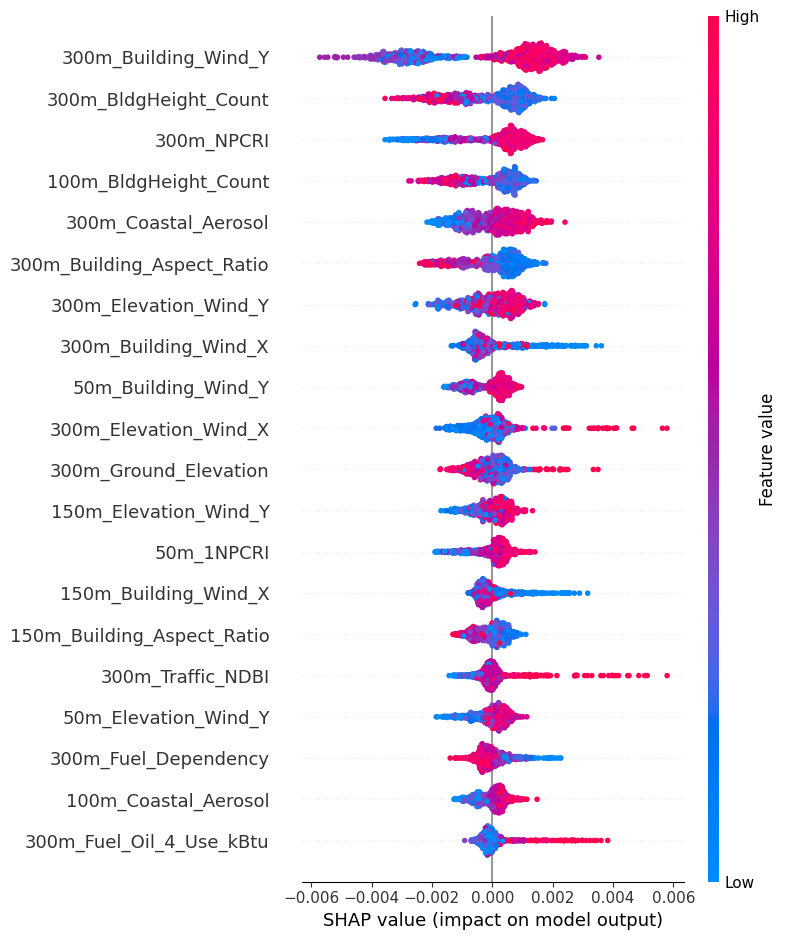

In [ ]:
explainer.summary_plot()

The most impactful features include **`300m_Building_Wind_Y`**, which represents the interaction between building height and wind flow, **`300m_BldgHeight_Count`**, which measures the number of tall buildings, and **`300m_Coastal_Aerosol`**, which accounts for aerosol concentrations in coastal regions. Additionally, **`300m_Elevation_Wind_X`**, which captures the influence of ground elevation on wind flow, also plays a significant role. These features suggest that **urban morphology and wind dynamics** are primary drivers of heat retention in urban environments.

The x-axis of the plot, which represents SHAP values, indicates how each feature contributes to the UHI index. Positive SHAP values suggest that a feature increases UHI, while negative values indicate a cooling effect. The color gradient in the plot provides additional insights—**red dots represent high feature values, while blue dots represent low values**. For example, in the case of **`Building_Wind_Y**, high values (red) are associated with **negative SHAP values**, suggesting that the **interaction of buildings in a 300 Meter buffer zone from the East-West direction reduces UHI**.

From a practical standpoint, the findings emphasize that **urban design plays a crucial role in mitigating heat islands**. The strong influence of **wind-building interactions** suggests that optimizing urban layouts to allow **better airflow** could help reduce UHI effects. Furthermore, since **vegetation is a key cooling factor**, increasing green spaces in **high-density, high-traffic areas** could be an effective strategy for heat reduction. Coastal aerosol concentrations and elevation also appear to influence temperature retention, which may be worth further investigation to refine mitigation strategies.

## Bar Plot

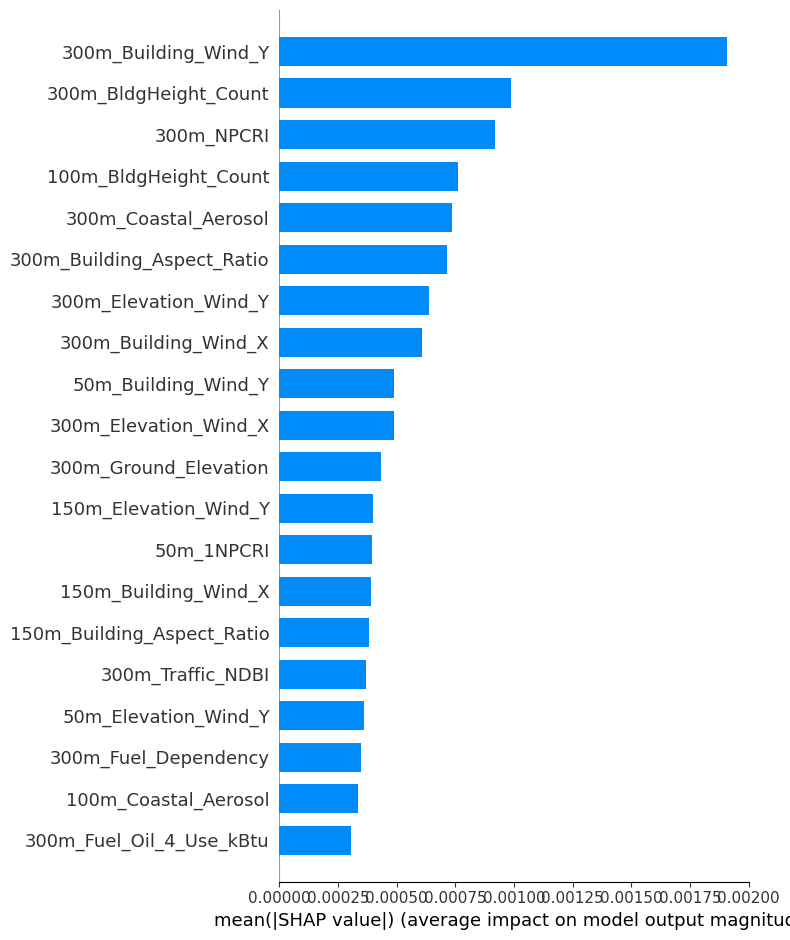

In [ ]:
explainer.bar_plot()

The most impactful features include **`300m_Building_Wind_Y and X`**, which represents the interaction between building height and wind flow, **`300m_BldgHeight_Count`**, which measures the number of tall buildings, and **`300m_Coastal_Aerosol`**, which accounts for aerosol concentrations in coastal regions. These features suggest that **urban morphology and wind dynamics** are primary drivers of heat retention in urban environments.

## Dependence Plot

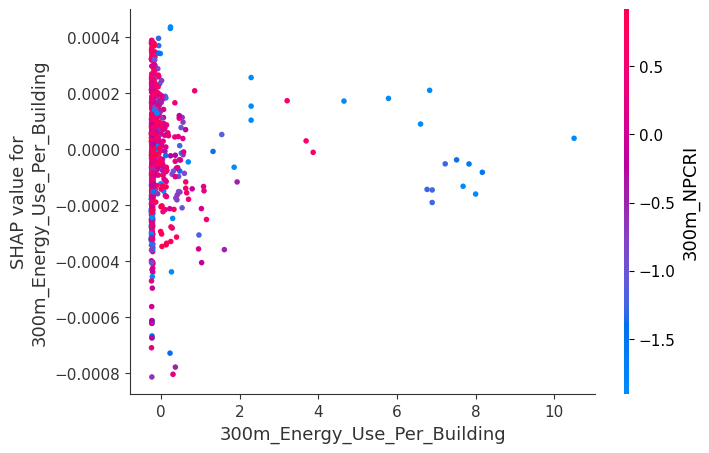

In [ ]:
explainer.dependence_plot("300m_Energy_Use_Per_Building")

This SHAP dependence plot illustrates the relationship between **energy use per building (300m_Energy_Use_Per_Building)** and its impact on the UHI model predictions. The x-axis represents energy use per building, while the y-axis shows the SHAP values, indicating how this feature contributes to the model's output. Most data points are clustered at lower energy use levels, with a mix of positive and negative SHAP values, suggesting that **energy consumption alone does not consistently increase or decrease UHI predictions**. However, at **higher energy use levels**, the impact becomes more negative, indicating that extreme energy consumption might correlate with lower UHI effects in certain cases, possibly due to efficient energy infrastructure or cooling mechanisms.

## Force Plot

Finally, we will explain an individual prediction. We can do this one by one for all predictions, but for now we will do the first one.

In [ ]:
#location index
record_index = 0

In [ ]:
#show location
submission_df.iloc[record_index, :]

,0
Longitude,-73.971665
Latitude,40.788763
UHI Index,0.964205


In [ ]:
shap.initjs()
explainer.force_plot(index=record_index)

In the **`force_plot`**, we can see which features influenced the predicted **UHI value** for the first row of the test dataset, corresponding to the location **(-73.971665, 40.788763)**. The most influential factors were **`300m_Building_Wind_Y`** and **`300m_BldgHeight_Count`**. These two pulled the UHI lower.

Other features also contributed to reducing the **UHI prediction**, including **`100m_BldgHeight_Count`**, which further lowered the value. Since the final **predicted UHI value is 0.96**, this suggests that the location is **cooler** than other locations, which means it is not experiencing the urban heat island effect.

# Summary Table

In [ ]:
# create the summary table
models = ['mixed_buffers_RandomForestRegressor_model']

data = {
    'Model': models,
    'Training R-squared': [insample_r2],
    'Validation R-squared': [outsample_r2]
}

summary_df = pd.DataFrame(data)
summary_df

,Model,Training R-squared,Validation R-squared
0,mixed_buffers_RandomForestRegressor_model,1.0,0.969685


# Save The Model

Now we will save both the model and the scaler.

In [ ]:
# Save the model and scaler to files
with open('mixed_buffers_RandomForestRegressor_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('mixed_buffers_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Conclusion

To conclude, the **Mixed Buffer `RandomForestRegressor`** performed exceptionally well, demonstrating a strong ability to model and predict **Urban Heat Island (UHI) effects**. The model effectively captured **complex relationships** between urban morphology, environmental factors, and climatic variables, showcasing its capability to handle **non-linear interactions** and **feature dependencies**.

Although, it performed relatively the same as our **tuned 300m `RandomForestRegressor`**. Meaning adding the mixed buffer zone variables slightly helped in predicting UHI values.